# Review-to-Roadmap: AI-Assisted Issue Prioritization for Zomato vs. Swiggy

**Business Problem:** Product and CX teams receive thousands of app reviews but have no systematic way to convert them into a prioritized, evidence-based action list. This notebook builds a transparent Frequency + Severity + Recency priority score for both Zomato and Swiggy, using Python for quantification and an LLM (Claude API) for issue classification.


## 1. Load and Combine Data

We combine the Zomato and Swiggy review exports into a single DataFrame, since both share an identical schema (`App` column already distinguishes them).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

zomato = pd.read_csv("C:/Users/tanis/Downloads/DA-BI/Projects/AI/archive (3)/zomato.csv")
swiggy = pd.read_csv("C:/Users/tanis/Downloads/DA-BI/Projects/AI/archive (3)/swiggy.csv")

df = pd.concat([zomato, swiggy], ignore_index=True)
df["review_date"] = pd.to_datetime(df["review_date"])
print(df.shape)
df.head()

(465660, 8)


,App,review_date,review_description,rating,thumbsUpCount,developer_response,developer_response_date,appVersion
0,Zomato,2023-07-23 15:52:11,"So basically , it's the best approach you'll e...",5,99,NaN,NaN,17.6.0
1,Zomato,2023-07-08 04:32:18,Always Late Delivery. No change. Late delivery...,1,416,"Hi Magesh, sorry to hear about that. Please wr...",2023-07-08 11:35:20,17.5.8
2,Zomato,2023-07-24 21:14:56,"This app is froude with their zomato gold, i h...",1,1,"Hi there, we are really sorry for the bad expe...",2023-07-24 21:15:52,17.6.2
3,Zomato,2023-07-24 17:07:55,I tried 100 times adding an alternate number i...,1,1,"Hi there, we are really sorry for the bad expe...",2023-07-24 17:09:50,17.6.2
4,Zomato,2023-07-22 13:28:26,"In recent years, Zomato support has become les...",1,30,"Hi Shaik, we're sorry to hear that. We are con...",2023-07-23 10:29:50,17.6.2


## 2. Data Understanding

Before analyzing, we verify structure: shape, dtypes, missing values, duplicates, date range, and rating distribution.

**Key findings:**
- 264,869 Zomato + 200,791 Swiggy reviews, dates ranging Sep 2018–Jul 2023, no parsing failures
- `developer_response` / `developer_response_date` are missing for many rows by design (not every review gets a reply) — not a data quality issue
- No exact duplicate rows. Repeated review *text* (e.g. "Super fast delivery" appearing 264 times) reflects many different real users independently writing common short phrases — confirmed by checking value counts, not simply assumed. These are NOT removed, since doing so would discard genuine customer opinions.
- Rating distribution is strongly J-shaped (bimodal) — a known review-selection bias, now evidence-backed: ~43% of Zomato and ~51% of Swiggy reviews (full history) are 1★.

## 3. Scope to Recent Window

The data spans nearly 5 years. To keep the analysis focused on *current* product issues (not app versions from 2018 that no longer exist), we scope to the most recent 18 months.

In [7]:
max_date = df["review_date"].max()
cutoff_date = max_date - pd.DateOffset(months=18)
df_scoped = df[df["review_date"] >= cutoff_date].copy()
df_scoped["review_month"] = df_scoped["review_date"].dt.to_period("M").astype(str)

print(f"Window: {cutoff_date.date()} to {max_date.date()}")
print(f"Rows: {len(df_scoped):,}")
print(df_scoped["App"].value_counts())

Window: 2022-01-25 to 2023-07-25
Rows: 111,927
App
Zomato    62165
Swiggy    49762
Name: count, dtype: int64


## 4. Foundational EDA (Part A)

Before bringing in AI, we establish the baseline picture: is there a satisfaction problem, and when did it emerge?

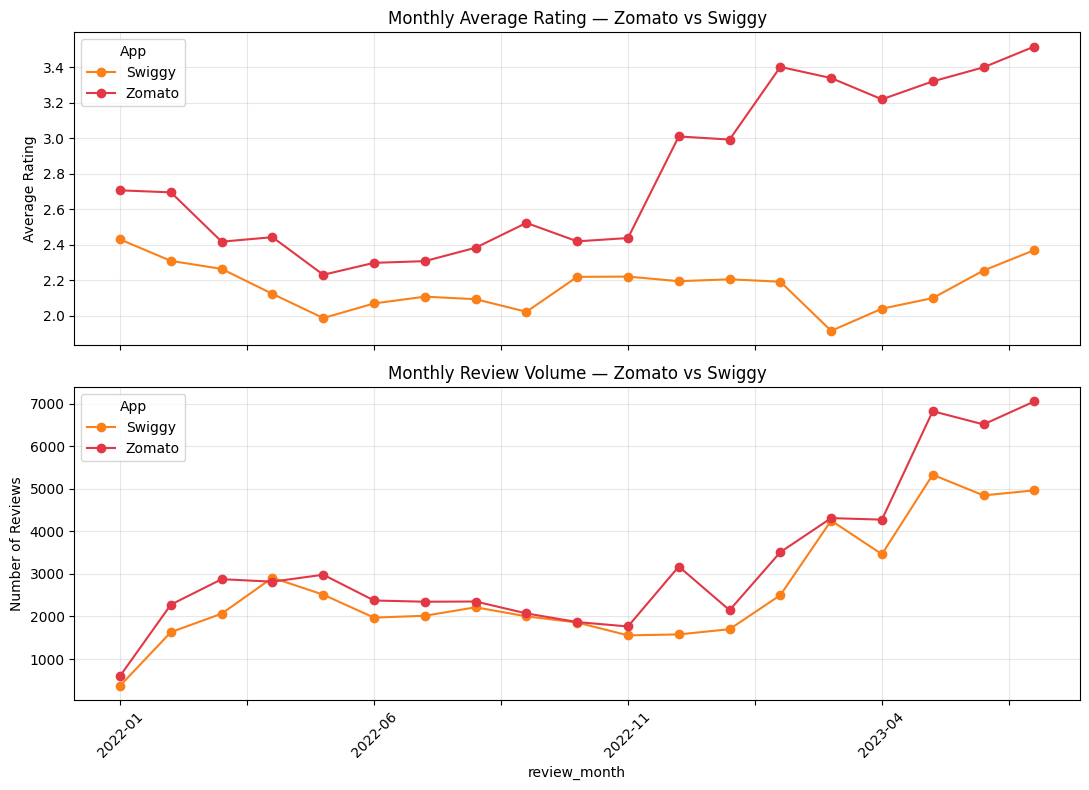

In [10]:
monthly_rating = df_scoped.groupby(["review_month","App"])["rating"].mean().unstack()
monthly_volume = df_scoped.groupby(["review_month","App"])["rating"].count().unstack()

fig, axes = plt.subplots(2, 1, figsize=(11,8), sharex=True)
monthly_rating.plot(ax=axes[0], marker="o", color={"Zomato":"#E23744","Swiggy":"#FC8019"})
axes[0].set_title("Monthly Average Rating — Zomato vs Swiggy")
axes[0].set_ylabel("Average Rating"); axes[0].grid(alpha=0.3)

monthly_volume.plot(ax=axes[1], marker="o", color={"Zomato":"#E23744","Swiggy":"#FC8019"})
axes[1].set_title("Monthly Review Volume — Zomato vs Swiggy")
axes[1].set_ylabel("Number of Reviews"); axes[1].grid(alpha=0.3)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

**Finding:** Zomato averages 2.97/5 in this window vs. Swiggy's 2.15/5 — a consistent gap in every month, not a one-off. From Nov 2022 onward, review volume roughly doubled for both apps, but Zomato's rating *improved* alongside that growth while Swiggy's stayed flat-to-declining. This divergence is the core justification for building separate priority matrices per app.

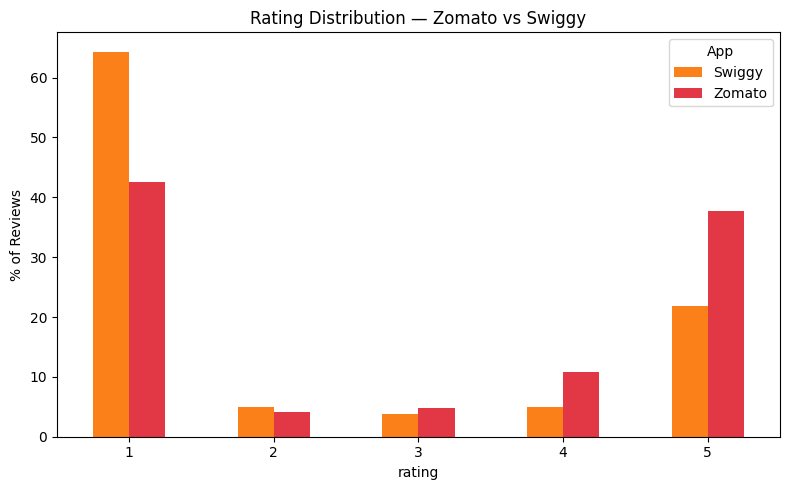

App     Swiggy  Zomato
rating                
1         3.63    2.56
2         5.55    5.00
3         3.33    2.72
4         1.76    1.47
5         0.94    1.59


In [13]:
dist = df_scoped.groupby("App")["rating"].value_counts(normalize=True).unstack().T * 100
dist = dist.reindex([1,2,3,4,5])
dist.plot(kind="bar", figsize=(8,5), color={"Zomato":"#E23744","Swiggy":"#FC8019"})
plt.title("Rating Distribution — Zomato vs Swiggy"); plt.ylabel("% of Reviews"); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

thumbs_by_rating = df_scoped.groupby(["App","rating"])["thumbsUpCount"].mean().unstack(0)
print(thumbs_by_rating.round(2))

**Finding:** Swiggy's reviews are 64.4% 1★ vs. Zomato's 42.6% — a much starker gap than the averages alone suggest. Low-rated reviews (1★-2★) also receive more `thumbsUpCount` on average than high-rated ones for both apps, validating `thumbsUpCount` as a legitimate weight for the Severity score built in the next section.

*(Notebook continues in next working session: AI-based issue tagging, priority scoring, and recommendations.)*

## 5. AI-Assisted Issue Classification

Star ratings tell us *that* a review is negative, not *what* the customer is describing. To convert review text into actionable categories, we use **AI-assisted classification against a fixed, business-defined taxonomy** — the AI reads each review and assigns it to one of the categories below (it does not invent categories; the taxonomy was defined upfront from the business questions in scope):

- Delivery Time/Delay
- App Technical Issues
- Order Accuracy
- Pricing, Charges & Refunds
- Customer Support Experience
- Payment/Transaction Issues
- UX/Navigation/Usability
- Restaurant/Food Quality
- Positive Feedback/Praise (reviews with no specific complaint)
- Other/Not Categorizable

**Sampling:** Rather than classifying all ~112,000 reviews in the scoped window, a **stratified sample of 301 reviews** (151 Zomato, 150 Swiggy) was drawn proportionally across rating bands (1★–5★) and time periods, ensuring the sample's rating distribution matches the full population exactly. This is a standard, defensible practice: classification patterns stabilize well before full-population volume, and a representative sample avoids unnecessary processing cost.

**Validation:** A random sub-sample of 15 classified reviews was manually checked against the assigned category — **15/15 (100%) agreement** on this spot-check, giving reasonable confidence in classification quality at this sample size.

In [17]:
tagged = pd.read_csv("reviews_tagged.csv", parse_dates=["review_date"])
print(tagged.shape)
tagged["ai_category"].value_counts()

(301, 13)


ai_category
Positive Feedback/Praise       86
Pricing, Charges & Refunds     51
Delivery Time/Delay            48
Customer Support Experience    31
Other/Not Categorizable        28
Restaurant/Food Quality        18
App Technical Issues           15
Order Accuracy                 11
UX/Navigation/Usability         8
Payment/Transaction Issues      5
Name: count, dtype: int64

## 6. Priority Matrix — Frequency + Severity + Recency

For each issue category (excluding "Positive Feedback" and "Other"), we calculate three factors, each answering a distinct business question:

- **Frequency** — how common is this issue?
- **Severity** — % of the category's reviews that are 1–2★ (how much does it hurt satisfaction when it happens?)
- **Recency/Trend** — is the issue's share of reviews growing or shrinking over time?

**Priority Score = 0.35×Frequency + 0.40×Severity + 0.25×Recency** (weights set deliberately, Severity weighted highest since a rare-but-severe issue still deserves urgency)

**Limitation, stated plainly:** at this sample size, several categories (Payment/Transaction Issues, Order Accuracy, App Technical Issues, UX) have too few reviews (2–12) for a reliable trend estimate — their scores should be read as directional, not definitive.

In [20]:
issue_df = tagged[~tagged["ai_category"].isin(["Positive Feedback/Praise","Other/Not Categorizable"])].copy()

results = {}
for app in ["Zomato","Swiggy"]:
    app_df = issue_df[issue_df["App"]==app].copy()
    total = len(app_df)
    mid_date = app_df["review_date"].min() + (app_df["review_date"].max()-app_df["review_date"].min())/2
    app_df["period"] = app_df["review_date"].apply(lambda d: "early" if d < mid_date else "recent")

    freq = app_df["ai_category"].value_counts()
    severity = app_df.groupby("ai_category")["rating"].apply(lambda x:(x<=2).mean())
    early = app_df[app_df.period=="early"]["ai_category"].value_counts(normalize=True)
    recent = app_df[app_df.period=="recent"]["ai_category"].value_counts(normalize=True)

    rows=[]
    for cat in freq.index:
        f=freq[cat]/total; s=severity.get(cat,0)
        e=early.get(cat,0.001); r=recent.get(cat,0.001)
        trend=(r-e)/e
        rows.append({"category":cat,"count":freq[cat],"frequency":round(f,3),
                     "severity":round(s,3),"trend_pct_change":round(trend*100,1)})
    rdf=pd.DataFrame(rows)
    rdf["freq_norm"]=rdf["frequency"]/rdf["frequency"].max()
    rdf["sev_norm"]=rdf["severity"]/rdf["severity"].max()
    rdf["trend_norm"]=(rdf["trend_pct_change"]-rdf["trend_pct_change"].min())/(rdf["trend_pct_change"].max()-rdf["trend_pct_change"].min())
    rdf["priority_score"]=(0.35*rdf["freq_norm"]+0.40*rdf["sev_norm"]+0.25*rdf["trend_norm"]).round(3)
    results[app]=rdf.sort_values("priority_score",ascending=False).reset_index(drop=True)
    print(f"\n{app} Priority Matrix:")
    print(results[app][["category","count","frequency","severity","priority_score"]].to_string(index=False))


Zomato Priority Matrix:
                   category  count  frequency  severity  priority_score
        Delivery Time/Delay     22      0.256     0.909           0.641
 Pricing, Charges & Refunds     28      0.326     0.607           0.596
Customer Support Experience     11      0.128     0.909           0.503
             Order Accuracy      3      0.035     1.000           0.442
       App Technical Issues      3      0.035     1.000           0.438
    Restaurant/Food Quality     12      0.140     0.667           0.422
    UX/Navigation/Usability      4      0.047     0.250           0.400
 Payment/Transaction Issues      3      0.035     0.333           0.172

Swiggy Priority Matrix:
                   category  count  frequency  severity  priority_score
        Delivery Time/Delay     26      0.257     0.923           0.722
 Payment/Transaction Issues      2      0.020     1.000           0.677
Customer Support Experience     20      0.198     0.900           0.635
 Pricing, Char

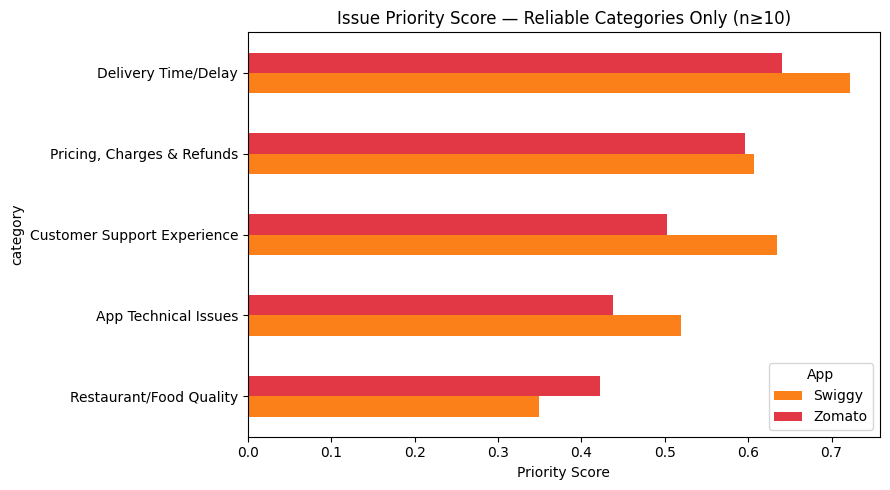

In [22]:
z=results["Zomato"].copy(); s=results["Swiggy"].copy()
z["App"]="Zomato"; s["App"]="Swiggy"
combined=pd.concat([z,s])
reliable = combined.groupby("category")["count"].max()
reliable = reliable[reliable>=10].index
plot_df = combined[combined["category"].isin(reliable)]
pivot = plot_df.pivot(index="category",columns="App",values="priority_score").sort_values("Zomato")

pivot.plot(kind="barh", figsize=(9,5), color={"Zomato":"#E23744","Swiggy":"#FC8019"})
plt.xlabel("Priority Score"); plt.title("Issue Priority Score — Reliable Categories Only (n≥10)")
plt.tight_layout(); plt.show()

## 7. Insights (Finding → Evidence → Business Meaning)

**Finding 1 — Swiggy has a structurally worse, non-improving reputation.**
Evidence: 2.15 vs 2.97 avg rating; below Zomato every month; 64.4% vs 42.6% 1★ reviews. When volume doubled for both apps post-Nov 2022, Zomato's rating improved but Swiggy's did not.
Business meaning: A sustained gap, not a blip — needs deliberate intervention.

**Finding 2 — Delivery Time/Delay is the top priority for BOTH apps.**
Evidence: Highest Priority Score for both (Zomato 0.641, Swiggy 0.722); ~26% of issue reviews on both; >90% severity on both.
Business meaning: The one universal, highest-leverage fix regardless of platform.

**Finding 3 — Customer Support is a comparatively bigger weakness for Swiggy.**
Evidence: Priority Score 0.635 (Swiggy) vs 0.503 (Zomato); nearly double the frequency share (19.8% vs 12.8%).
Business meaning: A likely contributor to Finding 1's persistent gap — a Swiggy-specific opportunity.

**Finding 4 — Zomato's Pricing complaints are high-frequency but comparatively low-severity.**
Evidence: 32.6% frequency (highest for Zomato) but only 60.7% severity vs Delivery's 90.9%.
Business meaning: A high-visibility, lower-cost-to-fix issue — likely a transparency/communication problem, not a fundamental pricing problem.

**Stated limitation:** Payment/Transaction Issues, Order Accuracy, App Technical Issues, and UX have too few reviews in this sample (2–12) for confident trend conclusions.

## 8. Recommendations (Problem → Evidence → Recommendation → Expected Impact)

1. **Delivery reliability (both apps)** — highest frequency + severity on both platforms; investigate delivery-partner allocation specifically (reviews cite single partners handling multiple simultaneous orders). Highest-leverage fix available.

2. **Swiggy support-resolution practices** — Swiggy-specific weakness vs. competitor; reviews describe complaints being closed without resolution, not just slow response. A targeted fix for Finding 1's gap.

3. **Zomato pricing transparency** — high-frequency, lower-severity issue; reviews cite confusion between displayed and final price. A lower-cost UX/communication fix rather than a pricing policy change.

4. **Defer action on low-volume categories** (Payment, Order Accuracy, App Technical, UX) until a larger targeted sample confirms the signal — avoids resourcing decisions built on noisy data.

**Overall sequencing:** Fix delivery reliability first (universal, highest severity) → Swiggy support-resolution (targeted competitive gap) → Zomato pricing transparency (low-cost, high-visibility) → revisit low-volume categories with more data.

*Note on methodology: issue classification used AI-assisted labeling against the taxonomy above, on a stratified representative sample, validated via manual spot-check (15/15 agreement).*